<a href="https://colab.research.google.com/github/juniti-y/RLseminar/blob/main/GymDemo01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# gymnasiumパッケージのインストール

In [ ]:
!pip install -q gymnasium
!pip install -q swig
!pip install -q "stable-baselines3[extra]"

## インストールが正常に完了したかを確認

In [ ]:
import gymnasium as gym

# CartPole環境オブジェクトを作成
env = gym.make("CartPole-v1")

# 環境を初期状態にリセット
observation, info = env.reset()

# いくつかのステップを実行
for _ in range(10):
    # actionをランダムサンプリング
    action = env.action_space.sample()
    # 状態を次状態に遷移し、観測値、報酬、終了状態に到達したかを取得
    observation, reward, terminated, truncated, info = env.step(action)
    # 終了状態に到達したら終了
    if terminated or truncated:
        observation, info = env.reset()

# 環境オブジェクトをクローズ
env.close()
print("Successfully finished")


# 環境から基本情報を得る

## 観測空間を取得


In [ ]:
# 環境オブジェクトを作成（CartPoleを例に）
env = gym.make("CartPole-v1")
# 観測空間を表示
print(env.observation_space)

## 行動空間を取得

In [ ]:
print(env.action_space)

## タスク実行状態の可視化
（Pendulumタスクを例に）

In [ ]:
import os
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
# env = gym.make("CartPole-v1", render_mode="rgb_array")
env = gym.make("Pendulum-v1", render_mode="rgb_array")
trigger = lambda t: t % 10 == 0 #動画を保存をするエピソードの指定
env = gym.wrappers.RecordVideo(env, video_folder="./", episode_trigger=trigger, disable_logger=True)
# 50エピソードランダムアクションで実行し、動画を保存
for i in range(50):
  env.reset(seed=123)
  termination, truncation = False, False
  while not (termination or truncation):
    obs, rew, termination, truncation, info = env.step(env.action_space.sample()) #policyはランダム
env.close()

実行後に、「rl-video-episode-0.mp4」のようなファイルが作成されているので、それを動画プレーヤで再生する。

# 公開ライブラリ（stable_baselines3）の強化学習モデルを使って学習する

## 必要なモジュールの呼び出し

In [51]:
import gymnasium as gym
from stable_baselines3 import PPO
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.monitor import Monitor
import pandas as pd
import matplotlib.pyplot as plt

## 環境を作成（CartPoleを例に）

In [52]:
env = gym.make("CartPole-v1")
# 学習ログを指定したフォルダに保存するようにする
env = Monitor(env, "./logs/")

## 学習エージェント（PPOエージェント）を作成

In [43]:
model = PPO(policy="MlpPolicy", env=env,verbose=1)

Using cpu device
Wrapping the env in a DummyVecEnv.


## 学習を実行する

In [44]:
model.learn(total_timesteps=10000)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.2     |
|    ep_rew_mean     | 22.2     |
| time/              |          |
|    fps             | 978      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.9        |
|    ep_rew_mean          | 25.9        |
| time/                   |             |
|    fps                  | 812         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007888203 |
|    clip_fraction        | 0.0868      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.687      |
|    explained_variance   | 0.00506     |
|    learning_rate        | 0.

## 学習済みモデルを保存する

In [45]:
model.save("ppo_cartpole")

## 環境を一旦クローズして、学習フェーズを終了する

In [46]:
env.close()

## 学習曲線の表示

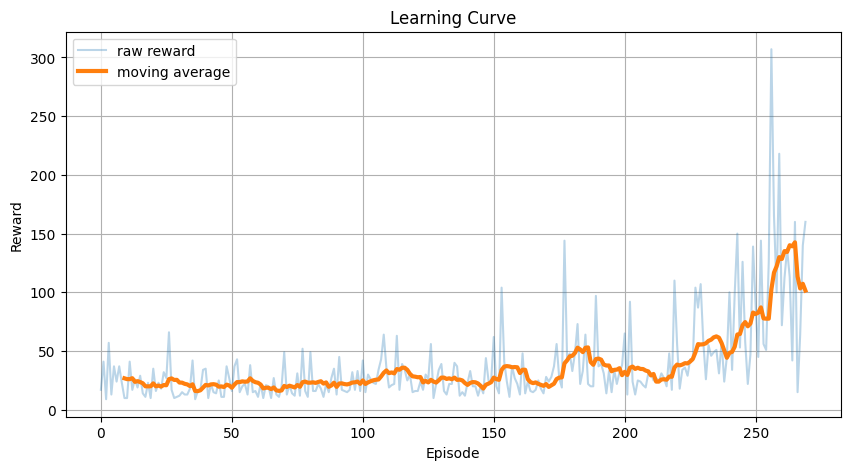

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [47]:
# monitor.csv を読み込む
df = pd.read_csv(
    "./logs/monitor.csv",
    skiprows=1
)

# 移動平均を計算
reward_smooth = df["r"].rolling(window=10).mean()

# グラフ描画
plt.figure(figsize=(10,5))

# 生データ
plt.plot(
    df["r"],
    alpha=0.3,
    label="raw reward"
)

# 移動平均
plt.plot(
    reward_smooth,
    linewidth=3,
    label="moving average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

## テストフェーズ（学習済みモデルを実際に環境で動かす）

In [50]:
# 動画作成モードで環境を作成
env = gym.make("CartPole-v1", render_mode="rgb_array")
env = gym.wrappers.RecordVideo(env, video_folder="./", disable_logger=True, name_prefix="ppo_cartpole_video")

# 保存した学習済みモデルをロード
model = PPO.load("ppo_cartpole", env=env)

# 環境を初期状態にリセット
obs, info = env.reset()
# 1試行分を動画記録付きで実行
for step in range(1000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


# 自由課題：タスクを変更したり、学習モデルを変更して学習の様子を観察してみる
（下記にCartporl課題+PPO学習モデルのフルコードを提示するのでそれを編集するところから始めると良い）

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.9     |
|    ep_rew_mean     | 22.9     |
| time/              |          |
|    fps             | 1218     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


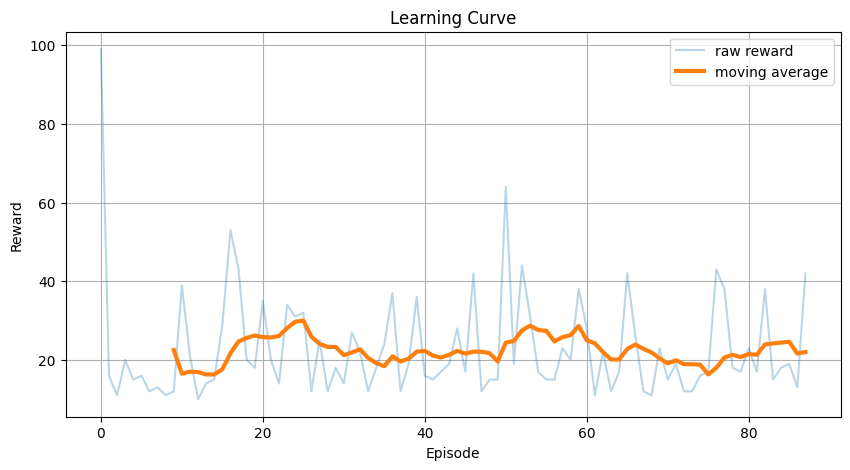

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [54]:
#############################################
# 定数の定義
#############################################
task_name = "CartPole-v1"
policy_model = "MlpPolicy"
model_file = "ppo_cartpole"
video_file_prefix = "ppo_cartpole_video"
log_dir = "./logs/"

#############################################
# モジュールの読み込み
#############################################

import gymnasium as gym
from stable_baselines3 import PPO
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.monitor import Monitor
import pandas as pd
import matplotlib.pyplot as plt

#############################################
# 環境を作る
#############################################
env = gym.make(task_name)
env = Monitor(env, log_dir)

#############################################
# 学習エージェント（PPOエージェント）を作成
#############################################

model = PPO(policy=policy_model, env=env,verbose=1)

#############################################
# 学習の実行とモデルの保存
#############################################

model.learn(total_timesteps=1000)
model.save(model_file)
env.close()

#############################################
# 学習曲線の表示
#############################################

# monitor.csv を読み込む
df = pd.read_csv(
    "./logs/monitor.csv",
    skiprows=1
)

# 移動平均を計算
reward_smooth = df["r"].rolling(window=10).mean()

# グラフ描画
plt.figure(figsize=(10,5))

# 生データ
plt.plot(
    df["r"],
    alpha=0.3,
    label="raw reward"
)

# 移動平均
plt.plot(
    reward_smooth,
    linewidth=3,
    label="moving average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

#############################################
# テストフェーズの実行
#############################################

# 動画作成モードで環境を作成
env = gym.make(task_name, render_mode="rgb_array")
env = gym.wrappers.RecordVideo(env, video_folder="./", disable_logger=True, name_prefix=video_file_prefix)

# 保存した学習済みモデルをロード
model = PPO.load(model_file, env=env)

# 環境を初期状態にリセット
obs, info = env.reset()
# 1試行分を動画記録付きで実行
for step in range(3000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()
env.close()


## 参考
Gymnasiumの代表的な環境としては以下のようなものがある

*   MountainCar: "MountainCar-v0"
*   Pendulum: "Pendulum-v1"
*   Acrobot: "Acrobot-v1"

Stable-Baselines3 の代表的モデルとしては以下のようなものがある
*   DQN: 離散行動
*   PPO: 離散／連続行動
*   A2C: 離散／連続行動
*   SAC: 連続行動
*   TD3: 連続行動
*   DDPG: 連続行動

### PPOのモデル作成

In [ ]:
# 例：環境によってはエラーが出るので注意
from stable_baselines3 import PPO
model = PPO(
    "MlpPolicy",
    env,
    verbose=1
)

### DQNのモデル作成

In [ ]:
# 例：環境によってはエラーが出るので注意
from stable_baselines3 import DQN
model = DQN(
    "MlpPolicy",
    env,
    verbose=1
)

### A2Cのモデル作成

In [ ]:
# 例：環境によってはエラーが出るので注意
from stable_baselines3 import A2C
model = PPO(
    "MlpPolicy",
    env,
    verbose=1
)

### SACのモデル作成

In [ ]:
# 例：環境によってはエラーが出るので注意
from stable_baselines3 import SAC
model = SAC(
    "MlpPolicy",
    env,
    verbose=1
)

### TD3のモデル作成

In [ ]:
# 例：環境によってはエラーが出るので注意
from stable_baselines3 import TD3

model = TD3(
   "MlpPolicy",
    env,
    verbose=1
)

### DDPGのモデル作成

In [ ]:
# 例：環境によってはエラーが出るので注意
from stable_baselines3 import DDPG
model = DDPG(policy= "MlpPolicy", env=env, verbose=1)

### 代表的なpolicyオプション
*   MlpPolicy: ベクトル入力
*   CnnPolicy: 画像入力
*   MultiInputPolicy: 複数入力（画像＋数値＋センサ）
*   MultiInputActorCriticPolicy: Dict観測